# 04 — Preprocessing Feature Matrix

Goal:
- Load the generated 21 cm dataset.
- Inspect feature and target ranges.
- Construct train/test splits.
- Apply StandardScaler preprocessing.
- Save ML-ready datasets for baselines and symbolic regression.

Inputs:
- feature_matrix_n100_validation.npy
- target_matrix_n100_validation.npy
- feature_names_n100_validation.csv
- target_names_n100_validation.csv

Outputs:
- raw train/test arrays
- standardized train/test arrays
- log-transformed + standardized train/test arrays
- fitted scalers
- preprocessing metadata

In [1]:
from pathlib import Path
import json
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
PROJECT_ROOT = Path("..").resolve()

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES = PROJECT_ROOT / "figures"
LOGS = PROJECT_ROOT / "logs"

for path in [DATA_PROCESSED, FIGURES, LOGS]:
    path.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Processed data:", DATA_PROCESSED)
print("Figures:", FIGURES)
print("Logs:", LOGS)

Project root: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression
Processed data: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/data/processed
Figures: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures
Logs: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/logs


In [3]:
DATA_TAG = "n100_validation"

feature_matrix_path = DATA_PROCESSED / f"feature_matrix_{DATA_TAG}.npy"
target_matrix_path = DATA_PROCESSED / f"target_matrix_{DATA_TAG}.npy"
feature_names_path = DATA_PROCESSED / f"feature_names_{DATA_TAG}.csv"
target_names_path = DATA_PROCESSED / f"target_names_{DATA_TAG}.csv"
generation_metadata_path = DATA_PROCESSED / f"dataset_generation_metadata_{DATA_TAG}.json"

print("Feature matrix:", feature_matrix_path)
print("Target matrix:", target_matrix_path)
print("Feature names:", feature_names_path)
print("Target names:", target_names_path)
print("Generation metadata:", generation_metadata_path)

Feature matrix: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/data/processed/feature_matrix_n100_validation.npy
Target matrix: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/data/processed/target_matrix_n100_validation.npy
Feature names: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/data/processed/feature_names_n100_validation.csv
Target names: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/data/processed/target_names_n100_validation.csv
Generation metadata: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/data/processed/dataset_generation_metadata_n100_validation.json


In [4]:
X = np.load(feature_matrix_path)
y = np.load(target_matrix_path)

feature_names_df = pd.read_csv(feature_names_path)
target_names_df = pd.read_csv(target_names_path)

with open(generation_metadata_path, "r") as f:
    generation_metadata = json.load(f)

feature_names = feature_names_df["feature_name"].tolist()
target_names = target_names_df["target_name"].tolist()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of feature names:", len(feature_names))
print("Number of target names:", len(target_names))

print("Target names:", target_names)

X shape: (100, 57)
y shape: (100, 5)
Number of feature names: 57
Number of target names: 5
Target names: ['zeta', 'log10_Tvir', 'R_mfp', 'log10_LX', 'sigma8']


In [5]:
assert X.ndim == 2
assert y.ndim == 2

assert X.shape[0] == y.shape[0]
assert X.shape[1] == len(feature_names)
assert y.shape[1] == len(target_names)

assert np.all(np.isfinite(X))
assert np.all(np.isfinite(y))

assert X.shape == (100, 57)
assert y.shape == (100, 5)

print("Dataset validation passed.")

Dataset validation passed.


In [6]:
feature_summary = pd.DataFrame({
    "min": np.min(X, axis=0),
    "max": np.max(X, axis=0),
    "mean": np.mean(X, axis=0),
    "std": np.std(X, axis=0),
}, index=feature_names)

feature_summary.head()

,min,max,mean,std
delta2_z12.0_k0.08491,0.193271,4.467185,0.962128,0.640268
delta2_z12.0_k0.10379,0.280337,5.457803,1.408919,0.836509
delta2_z12.0_k0.12686,0.310674,7.259276,1.863893,1.152256
delta2_z12.0_k0.15507,1.185893,6.358464,2.972230,0.943088
delta2_z12.0_k0.18954,2.167765,8.095919,3.573659,0.944118


In [7]:
print("Global X statistics")
print("Min:", np.min(X))
print("Max:", np.max(X))
print("Mean:", np.mean(X))
print("Std:", np.std(X))
print("Percentiles [0, 1, 5, 50, 95, 99, 100]:")

percentiles = np.percentile(X, [0, 1, 5, 50, 95, 99, 100])
for p, val in zip([0, 1, 5, 50, 95, 99, 100], percentiles):
    print(f"  {p:>3}%: {val:.6e}")

Global X statistics
Min: 0.17289936725569016
Max: 82.64502842023994
Mean: 16.967262594184035
Std: 9.9575893798738
Percentiles [0, 1, 5, 50, 95, 99, 100]:
    0%: 1.728994e-01
    1%: 4.701960e-01
    5%: 1.335788e+00
   50%: 1.762341e+01
   95%: 3.327722e+01
   99%: 4.443421e+01
  100%: 8.264503e+01


In [8]:
target_summary = pd.DataFrame({
    "min": np.min(y, axis=0),
    "max": np.max(y, axis=0),
    "mean": np.mean(y, axis=0),
    "std": np.std(y, axis=0),
}, index=target_names)

target_summary

,min,max,mean,std
zeta,10.603814,79.936966,44.980624,20.184731
log10_Tvir,4.007671,5.485617,4.749817,0.433009
R_mfp,5.134531,29.870285,17.496203,7.226302
log10_LX,38.018583,41.995280,40.002766,1.155102
sigma8,0.751468,0.899231,0.825011,0.043228


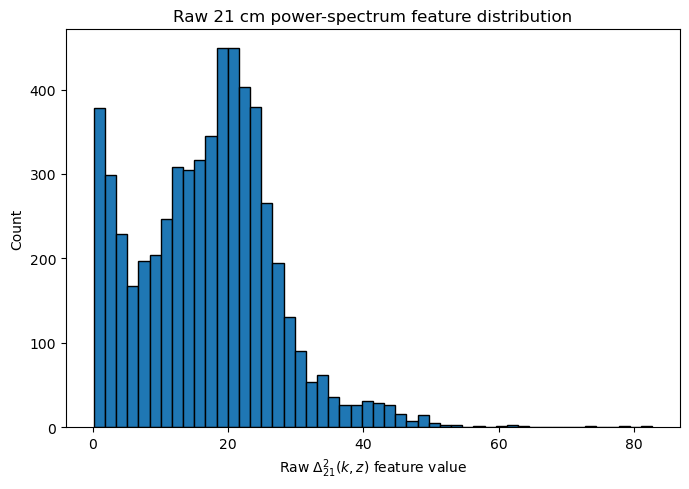

Saved figure to: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/raw_feature_distribution_n100_validation.png


In [9]:
plt.figure(figsize=(7, 5))

plt.hist(X.ravel(), bins=50, edgecolor="black")

plt.xlabel(r"Raw $\Delta^2_{21}(k,z)$ feature value")
plt.ylabel("Count")
plt.title("Raw 21 cm power-spectrum feature distribution")
plt.tight_layout()

raw_feature_hist_path = FIGURES / f"raw_feature_distribution_{DATA_TAG}.png"
plt.savefig(raw_feature_hist_path, dpi=300)
plt.show()

print("Saved figure to:", raw_feature_hist_path)

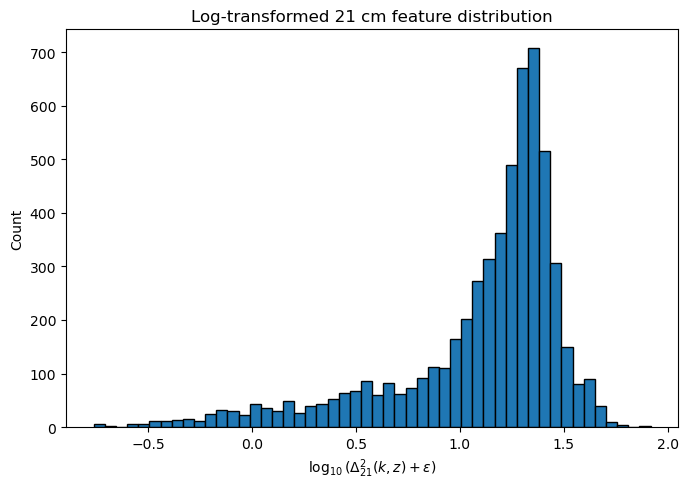

Saved figure to: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/log_feature_distribution_n100_validation.png


In [10]:
X_log_preview = np.log10(X + 1e-8)

plt.figure(figsize=(7, 5))

plt.hist(X_log_preview.ravel(), bins=50, edgecolor="black")

plt.xlabel(r"$\log_{10}(\Delta^2_{21}(k,z) + \epsilon)$")
plt.ylabel("Count")
plt.title("Log-transformed 21 cm feature distribution")
plt.tight_layout()

log_feature_hist_path = FIGURES / f"log_feature_distribution_{DATA_TAG}.png"
plt.savefig(log_feature_hist_path, dpi=300)
plt.show()

print("Saved figure to:", log_feature_hist_path)

In [11]:
RANDOM_SEED = 42
TEST_SIZE = 0.20

indices = np.arange(X.shape[0])

train_indices, test_indices = train_test_split(
    indices,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    shuffle=True,
)

X_train_raw = X[train_indices]
X_test_raw = X[test_indices]

y_train_raw = y[train_indices]
y_test_raw = y[test_indices]

print("Train size:", X_train_raw.shape[0])
print("Test size:", X_test_raw.shape[0])

print("X_train_raw shape:", X_train_raw.shape)
print("X_test_raw shape:", X_test_raw.shape)
print("y_train_raw shape:", y_train_raw.shape)
print("y_test_raw shape:", y_test_raw.shape)

Train size: 80
Test size: 20
X_train_raw shape: (80, 57)
X_test_raw shape: (20, 57)
y_train_raw shape: (80, 5)
y_test_raw shape: (20, 5)


In [12]:
assert len(set(train_indices).intersection(set(test_indices))) == 0
assert len(train_indices) + len(test_indices) == X.shape[0]

assert X_train_raw.shape[0] == y_train_raw.shape[0]
assert X_test_raw.shape[0] == y_test_raw.shape[0]

print("Train/test split validation passed.")

Train/test split validation passed.


In [13]:
feature_scaler_raw = StandardScaler()

X_train_scaled = feature_scaler_raw.fit_transform(X_train_raw)
X_test_scaled = feature_scaler_raw.transform(X_test_raw)

print("X_train_scaled mean:", np.mean(X_train_scaled))
print("X_train_scaled std:", np.std(X_train_scaled))
print("X_test_scaled shape:", X_test_scaled.shape)

assert np.all(np.isfinite(X_train_scaled))
assert np.all(np.isfinite(X_test_scaled))

X_train_scaled mean: -1.495879443705474e-16
X_train_scaled std: 1.0
X_test_scaled shape: (20, 57)


In [14]:
EPSILON = 1e-8

X_train_log_raw = np.log10(X_train_raw + EPSILON)
X_test_log_raw = np.log10(X_test_raw + EPSILON)

feature_scaler_log = StandardScaler()

X_train_log_scaled = feature_scaler_log.fit_transform(X_train_log_raw)
X_test_log_scaled = feature_scaler_log.transform(X_test_log_raw)

print("X_train_log_scaled mean:", np.mean(X_train_log_scaled))
print("X_train_log_scaled std:", np.std(X_train_log_scaled))
print("X_test_log_scaled shape:", X_test_log_scaled.shape)

assert np.all(np.isfinite(X_train_log_scaled))
assert np.all(np.isfinite(X_test_log_scaled))

X_train_log_scaled mean: 5.297906363123554e-16
X_train_log_scaled std: 1.0
X_test_log_scaled shape: (20, 57)


In [15]:
target_scaler = StandardScaler()

y_train_scaled = target_scaler.fit_transform(y_train_raw)
y_test_scaled = target_scaler.transform(y_test_raw)

print("y_train_scaled mean:", np.mean(y_train_scaled))
print("y_train_scaled std:", np.std(y_train_scaled))
print("y_test_scaled shape:", y_test_scaled.shape)

assert np.all(np.isfinite(y_train_scaled))
assert np.all(np.isfinite(y_test_scaled))

y_train_scaled mean: 7.105427357601002e-16
y_train_scaled std: 0.9999999999999998
y_test_scaled shape: (20, 5)


In [16]:
split_indices_path = DATA_PROCESSED / f"split_indices_{DATA_TAG}.npz"

np.savez(
    split_indices_path,
    train_indices=train_indices,
    test_indices=test_indices,
)

print("Saved split indices to:", split_indices_path)

Saved split indices to: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/data/processed/split_indices_n100_validation.npz


In [17]:
X_train_raw_path = DATA_PROCESSED / f"X_train_raw_{DATA_TAG}.npy"
X_test_raw_path = DATA_PROCESSED / f"X_test_raw_{DATA_TAG}.npy"
y_train_raw_path = DATA_PROCESSED / f"y_train_raw_{DATA_TAG}.npy"
y_test_raw_path = DATA_PROCESSED / f"y_test_raw_{DATA_TAG}.npy"

np.save(X_train_raw_path, X_train_raw)
np.save(X_test_raw_path, X_test_raw)
np.save(y_train_raw_path, y_train_raw)
np.save(y_test_raw_path, y_test_raw)

print("Saved raw train/test arrays.")

Saved raw train/test arrays.


In [18]:
X_train_scaled_path = DATA_PROCESSED / f"X_train_scaled_{DATA_TAG}.npy"
X_test_scaled_path = DATA_PROCESSED / f"X_test_scaled_{DATA_TAG}.npy"

X_train_log_scaled_path = DATA_PROCESSED / f"X_train_log_scaled_{DATA_TAG}.npy"
X_test_log_scaled_path = DATA_PROCESSED / f"X_test_log_scaled_{DATA_TAG}.npy"

y_train_scaled_path = DATA_PROCESSED / f"y_train_scaled_{DATA_TAG}.npy"
y_test_scaled_path = DATA_PROCESSED / f"y_test_scaled_{DATA_TAG}.npy"

np.save(X_train_scaled_path, X_train_scaled)
np.save(X_test_scaled_path, X_test_scaled)

np.save(X_train_log_scaled_path, X_train_log_scaled)
np.save(X_test_log_scaled_path, X_test_log_scaled)

np.save(y_train_scaled_path, y_train_scaled)
np.save(y_test_scaled_path, y_test_scaled)

print("Saved scaled train/test arrays.")

Saved scaled train/test arrays.


In [19]:
feature_scaler_raw_path = DATA_PROCESSED / f"feature_scaler_raw_{DATA_TAG}.joblib"
feature_scaler_log_path = DATA_PROCESSED / f"feature_scaler_log_{DATA_TAG}.joblib"
target_scaler_path = DATA_PROCESSED / f"target_scaler_{DATA_TAG}.joblib"

joblib.dump(feature_scaler_raw, feature_scaler_raw_path)
joblib.dump(feature_scaler_log, feature_scaler_log_path)
joblib.dump(target_scaler, target_scaler_path)

print("Saved scalers:")
print(" -", feature_scaler_raw_path)
print(" -", feature_scaler_log_path)
print(" -", target_scaler_path)

Saved scalers:
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/data/processed/feature_scaler_raw_n100_validation.joblib
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/data/processed/feature_scaler_log_n100_validation.joblib
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/data/processed/target_scaler_n100_validation.joblib


In [20]:
preprocessing_metadata = {
    "notebook": "04_preprocessing_feature_matrix.ipynb",
    "data_tag": DATA_TAG,
    "source_feature_matrix": str(feature_matrix_path),
    "source_target_matrix": str(target_matrix_path),
    "n_samples": int(X.shape[0]),
    "n_features": int(X.shape[1]),
    "n_targets": int(y.shape[1]),
    "target_names": target_names,
    "test_size": TEST_SIZE,
    "random_seed": RANDOM_SEED,
    "feature_representations": {
        "raw_scaled": "StandardScaler applied to raw Delta^2_21 features",
        "log_scaled": "log10(Delta^2_21 + epsilon) followed by StandardScaler",
    },
    "epsilon_for_log": EPSILON,
    "notes": (
        "Both raw-standardized and log-standardized feature versions are saved. "
        "The log-standardized version may improve symbolic-regression stability "
        "because 21 cm power spectra span a broad dynamic range."
    ),
}

preprocessing_metadata_path = DATA_PROCESSED / f"preprocessing_metadata_{DATA_TAG}.json"

with open(preprocessing_metadata_path, "w") as f:
    json.dump(preprocessing_metadata, f, indent=2)

print("Saved preprocessing metadata to:", preprocessing_metadata_path)

Saved preprocessing metadata to: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/data/processed/preprocessing_metadata_n100_validation.json


In [21]:
feature_summary_path = DATA_PROCESSED / f"feature_summary_{DATA_TAG}.csv"
target_summary_path = DATA_PROCESSED / f"target_summary_{DATA_TAG}.csv"

feature_summary.to_csv(feature_summary_path)
target_summary.to_csv(target_summary_path)

print("Saved summary tables:")
print(" -", feature_summary_path)
print(" -", target_summary_path)

Saved summary tables:
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/data/processed/feature_summary_n100_validation.csv
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/data/processed/target_summary_n100_validation.csv


In [22]:
loaded_X_train_scaled = np.load(X_train_scaled_path)
loaded_X_test_scaled = np.load(X_test_scaled_path)

loaded_X_train_log_scaled = np.load(X_train_log_scaled_path)
loaded_X_test_log_scaled = np.load(X_test_log_scaled_path)

loaded_y_train_scaled = np.load(y_train_scaled_path)
loaded_y_test_scaled = np.load(y_test_scaled_path)

print("Loaded X_train_scaled:", loaded_X_train_scaled.shape)
print("Loaded X_test_scaled:", loaded_X_test_scaled.shape)
print("Loaded X_train_log_scaled:", loaded_X_train_log_scaled.shape)
print("Loaded X_test_log_scaled:", loaded_X_test_log_scaled.shape)
print("Loaded y_train_scaled:", loaded_y_train_scaled.shape)
print("Loaded y_test_scaled:", loaded_y_test_scaled.shape)

assert loaded_X_train_scaled.shape == X_train_scaled.shape
assert loaded_X_test_scaled.shape == X_test_scaled.shape
assert loaded_X_train_log_scaled.shape == X_train_log_scaled.shape
assert loaded_X_test_log_scaled.shape == X_test_log_scaled.shape
assert loaded_y_train_scaled.shape == y_train_scaled.shape
assert loaded_y_test_scaled.shape == y_test_scaled.shape

print("Reload validation passed.")

Loaded X_train_scaled: (80, 57)
Loaded X_test_scaled: (20, 57)
Loaded X_train_log_scaled: (80, 57)
Loaded X_test_log_scaled: (20, 57)
Loaded y_train_scaled: (80, 5)
Loaded y_test_scaled: (20, 5)
Reload validation passed.


In [23]:
print("=" * 60)
print("Notebook 04 completed successfully.")
print("=" * 60)

print("Dataset tag:", DATA_TAG)
print("Samples:", X.shape[0])
print("Features:", X.shape[1])
print("Targets:", y.shape[1])

print("\nTrain/test split:")
print("Train:", X_train_raw.shape[0])
print("Test:", X_test_raw.shape[0])

print("\nSaved files:")
print(" -", split_indices_path)
print(" -", X_train_raw_path)
print(" -", X_test_raw_path)
print(" -", y_train_raw_path)
print(" -", y_test_raw_path)
print(" -", X_train_scaled_path)
print(" -", X_test_scaled_path)
print(" -", X_train_log_scaled_path)
print(" -", X_test_log_scaled_path)
print(" -", y_train_scaled_path)
print(" -", y_test_scaled_path)
print(" -", feature_scaler_raw_path)
print(" -", feature_scaler_log_path)
print(" -", target_scaler_path)
print(" -", preprocessing_metadata_path)
print(" -", feature_summary_path)
print(" -", target_summary_path)

Notebook 04 completed successfully.
Dataset tag: n100_validation
Samples: 100
Features: 57
Targets: 5

Train/test split:
Train: 80
Test: 20

Saved files:
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/data/processed/split_indices_n100_validation.npz
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/data/processed/X_train_raw_n100_validation.npy
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/data/processed/X_test_raw_n100_validation.npy
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/data/processed/y_train_raw_n100_validation.npy
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/data/processed/y_test_raw_n100_validation.npy
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/data/processed/X_train_scaled_n100_validation.npy
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/data/processed/X_test_scaled_n100_validation.npy
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/data/processed/X_train_l